Number of Samples:
1797

Target Classes:
[0 1 2 3 4 5 6 7 8 9]

Accuracy for Different K Values:

K = 1 --> Accuracy = 0.9777777777777777
K = 2 --> Accuracy = 0.9805555555555555
K = 3 --> Accuracy = 0.9833333333333333
K = 4 --> Accuracy = 0.9805555555555555
K = 5 --> Accuracy = 0.9861111111111112
K = 6 --> Accuracy = 0.9888888888888889
K = 7 --> Accuracy = 0.9888888888888889
K = 8 --> Accuracy = 0.9861111111111112
K = 9 --> Accuracy = 0.9805555555555555
K = 10 --> Accuracy = 0.9833333333333333
K = 11 --> Accuracy = 0.9833333333333333
K = 12 --> Accuracy = 0.9777777777777777
K = 13 --> Accuracy = 0.9777777777777777
K = 14 --> Accuracy = 0.9805555555555555
K = 15 --> Accuracy = 0.9777777777777777

Best K Value:
6

Best Accuracy:
0.9888888888888889

Predictions:
[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8]

Actual Values:
[6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8]

Confusion Matrix:
[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 3

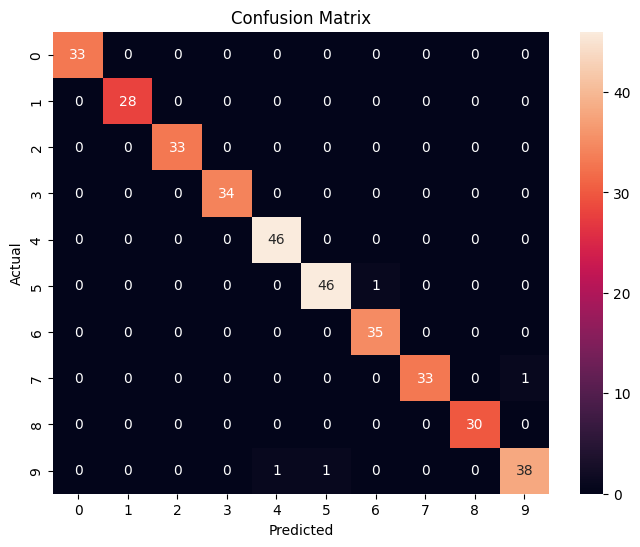


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       1.00      1.00      1.00        33
           3       1.00      1.00      1.00        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      1.00      1.00        30
           9       0.97      0.95      0.96        40

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360


Custom Sample Prediction:
6

Actual Digit:
6


In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load digits dataset
digits = load_digits()

# Display dataset information
print("Number of Samples:")
print(len(digits.data))

print("\nTarget Classes:")
print(digits.target_names)

# Define input features and target labels
X = digits.data
y = digits.target

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------
# Try Different K Values
# ---------------------------------------------------

scores = {}

print("\nAccuracy for Different K Values:\n")

for k in range(1, 16):

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    # Train model
    model.fit(X_train, y_train)

    # Accuracy
    score = model.score(X_test, y_test)

    scores[k] = score

    print(f"K = {k} --> Accuracy = {score}")

# ---------------------------------------------------
# Best K Value
# ---------------------------------------------------

best_k = max(scores, key=scores.get)

print("\nBest K Value:")
print(best_k)

print("\nBest Accuracy:")
print(scores[best_k])

# ---------------------------------------------------
# Train Final Model
# ---------------------------------------------------

final_model = KNeighborsClassifier(
    n_neighbors=best_k
)

final_model.fit(X_train, y_train)

# ---------------------------------------------------
# Predictions
# ---------------------------------------------------

predictions = final_model.predict(X_test)

print("\nPredictions:")
print(predictions[:20])

print("\nActual Values:")
print(y_test[:20])

# ---------------------------------------------------
# Confusion Matrix
# ---------------------------------------------------

cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ---------------------------------------------------
# Classification Report
# ---------------------------------------------------

report = classification_report(
    y_test,
    predictions
)

print("\nClassification Report:")
print(report)

# ---------------------------------------------------
# Custom Prediction
# ---------------------------------------------------

sample_prediction = final_model.predict(
    [X_test[0]]
)

print("\nCustom Sample Prediction:")
print(sample_prediction[0])

print("\nActual Digit:")
print(y_test[0])